In [8]:
import pandas as pd
import numpy as np
import os

os.chdir('/Users/jonathanzhu/Documents/ev work/allegheny')
df = pd.read_csv('dhs_cleaned.csv')

# Plotting
Making visualizations is a key part of EDAs. So in order to plot, we will use packages `matplotlib` and `seaborn` to make some nice-looking plots.

## Histograms
Histograms are a good way of looking at the overall distribution of a single feature, or column. 

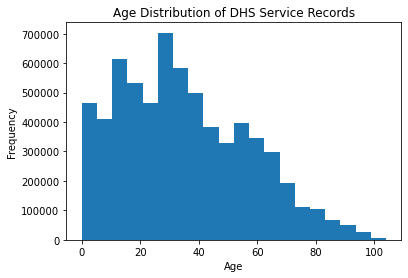

In [9]:
#here we want to make a histogram of the age column in the dataset
#using matplotlib.pyplot
import matplotlib.pyplot as plt

#since we already removed NA values, we can get straight to plotting
plt.hist(df['age'], bins=20)
#add some labels
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of DHS Service Records')
plt.show()

## Scatter Plots
For looking at the relationship between two numerical variables, we turn to scatterplots. We can also add trend lines if we think there may be a relationship between the two. Unfortunately this dataset does not have multiple numerical variables, so only age.

However, a variation of scatterplots can also be used to visualize relationships between categorical variables. Here, we will assign various levels of the categories to one axis, and the number of points to the other. The hue can be used as another variable.

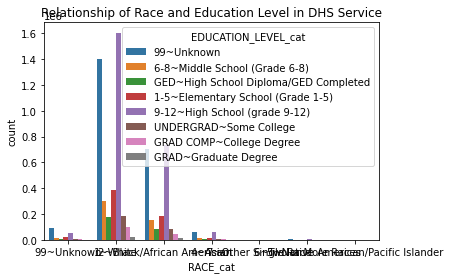

In [15]:
#making a seaborn countplot with x as RACE as x axis and EDUCATION_LEVEL as hue axis
import seaborn as sns

sns.countplot(data = df, x = "RACE_cat", hue = "EDUCATION_LEVEL_cat")
plt.title("Relationship of Race and Education Level in DHS Service")
plt.show()

## Boxplots
For looking at the relationship between two variables, one numeric and one categorical, we can use boxplots, which also give some information on the quartiles of the numeric variable.

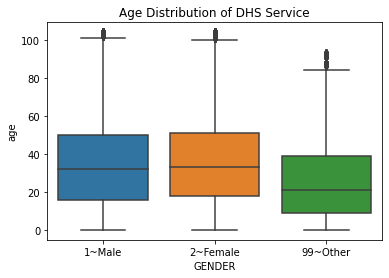

In [10]:
#we want to make a boxplot of age, separated by gender
#we can use seaborn for this
import seaborn as sns

sns.boxplot(data = df, x = "GENDER", y = "age")
plt.title('Age Distribution of DHS Service')
plt.show()

## Violin plots
A variation on the boxplot is the violin plot, which shows the relative distributions of each of the groups you are examining.

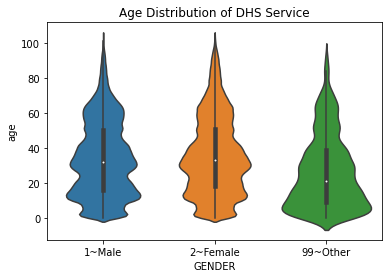

In [11]:
#we want to make the same as above, but with violin plots
sns.violinplot(data = df, x = "GENDER", y = "age")
plt.title('Age Distribution of DHS Service')
plt.show()

Note: I am not entirely sure what other plots to add due to the relative lack of numerical variables in this dataset. Age is really the only one. 



# Statistical Testing
While visualizations make for good reports and are a good way of visually looking at data, you can often get much more conclusive results about data by doing statistical tests. 

## Chi-Square Tests of Independence
A good way to compare two categorical datatypes is to use a chi-square test of independence. This can easily be called from packages in `scipy.stats`.

In [24]:
#we are going to do a chi-square test of independence
#to see if there is a relationship between RACE and EDUCATION_LEVEL
#we can use the scipy library for this
from scipy.stats import chi2_contingency

#first we get the categories from the race column
race_cats = df["RACE_cat"].astype('category').cat.categories
race = pd.Categorical(df["RACE_cat"], categories=race_cats)
#then same for education
edu_cats = df["EDUCATION_LEVEL_cat"].astype('category').cat.categories
edu = pd.Categorical(df["EDUCATION_LEVEL_cat"], categories=edu_cats)
#now the contingency table
tab = pd.crosstab(race, edu)

#now we can run the chi-square test
chi2, p, dof, expected = chi2_contingency(tab)
print("Chi-square test of independence: p = ", p, "chi2 = ", chi2)

Chi-square test of independence: p =  0.0 chi2 =  19200.2208703978


This incredibly high statistic and this very low p-value indicates that there is a dependency between race and education level. This may not be something we observed in the plots, especially with how many different levels we had for each category!